In [4]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_excel('D:\data_set\Flight_Price_resources (2)\Data_Train.xlsx')
df

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302
...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,9/04/2019,Kolkata,Banglore,CCU → BLR,19:55,22:25,2h 30m,non-stop,No info,4107
10679,Air India,27/04/2019,Kolkata,Banglore,CCU → BLR,20:45,23:20,2h 35m,non-stop,No info,4145
10680,Jet Airways,27/04/2019,Banglore,Delhi,BLR → DEL,08:20,11:20,3h,non-stop,No info,7229
10681,Vistara,01/03/2019,Banglore,New Delhi,BLR → DEL,11:30,14:10,2h 40m,non-stop,No info,12648


In [6]:
df.head(5)

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


##### Data Cleaning

In [8]:
df.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

In [9]:
df[df['Total_Stops'].isnull()]

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
9039,Air India,6/05/2019,Delhi,Cochin,NaN,09:45,09:25 07 May,23h 40m,NaN,No info,7480


In [10]:
df.dropna(inplace=True) 

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10682 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10682 non-null  object
 1   Date_of_Journey  10682 non-null  object
 2   Source           10682 non-null  object
 3   Destination      10682 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10682 non-null  object
 6   Arrival_Time     10682 non-null  object
 7   Duration         10682 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10682 non-null  object
 10  Price            10682 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 1001.4+ KB


In [12]:
data = df.copy()

In [13]:
data.columns

Index(['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Route',
       'Dep_Time', 'Arrival_Time', 'Duration', 'Total_Stops',
       'Additional_Info', 'Price'],
      dtype='object')

In [14]:
df.dtypes

Airline            object
Date_of_Journey    object
Source             object
Destination        object
Route              object
Dep_Time           object
Arrival_Time       object
Duration           object
Total_Stops        object
Additional_Info    object
Price               int64
dtype: object

In [15]:
import warnings
from warnings import filterwarnings
filterwarnings('ignore')

In [16]:
data.columns

Index(['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Route',
       'Dep_Time', 'Arrival_Time', 'Duration', 'Total_Stops',
       'Additional_Info', 'Price'],
      dtype='object')

In [17]:
def into_datetime(col):
    data[col] = pd.to_datetime(data[col])

In [18]:
for items in ['Dep_Time','Arrival_Time','Date_of_Journey'] :
    into_datetime(items)
    

In [19]:
data.dtypes

Airline                    object
Date_of_Journey    datetime64[ns]
Source                     object
Destination                object
Route                      object
Dep_Time           datetime64[ns]
Arrival_Time       datetime64[ns]
Duration                   object
Total_Stops                object
Additional_Info            object
Price                       int64
dtype: object

In [20]:
data['Day'] = data['Date_of_Journey'].dt.day  # Extracting features

In [21]:
data['Month'] = data['Date_of_Journey'].dt.month

In [22]:
data['Year'] = data['Date_of_Journey'].dt.year

In [23]:
data.head(3)

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Day,Month,Year
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,2026-03-10 22:20:00,2026-03-22 01:10:00,2h 50m,non-stop,No info,3897,24,3,2019
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,2026-03-10 05:50:00,2026-03-10 13:15:00,7h 25m,2 stops,No info,7662,1,5,2019
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,2026-03-10 09:25:00,2026-06-10 04:25:00,19h,2 stops,No info,13882,9,6,2019


In [24]:
''' Extracting features from dep_time column '''

def get_hr_min(dff , colm) :
    dff[colm+'_hr'] = dff[colm].dt.hour 
    dff[colm+'_min'] = dff[colm].dt.minute
    return dff.head(3)

In [25]:
get_hr_min(data,'Dep_Time')

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Day,Month,Year,Dep_Time_hr,Dep_Time_min
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,2026-03-10 22:20:00,2026-03-22 01:10:00,2h 50m,non-stop,No info,3897,24,3,2019,22,20
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,2026-03-10 05:50:00,2026-03-10 13:15:00,7h 25m,2 stops,No info,7662,1,5,2019,5,50
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,2026-03-10 09:25:00,2026-06-10 04:25:00,19h,2 stops,No info,13882,9,6,2019,9,25


In [26]:
drop_columns = ['Dep_Time' ,'Arrival_Time']   # drop extra columns

In [27]:
data.drop(drop_columns , axis = 1 , inplace = True)

In [28]:
data.head(3)

,Airline,Date_of_Journey,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Day,Month,Year,Dep_Time_hr,Dep_Time_min
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,2h 50m,non-stop,No info,3897,24,3,2019,22,20
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,7h 25m,2 stops,No info,7662,1,5,2019,5,50
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,19h,2 stops,No info,13882,9,6,2019,9,25


In [29]:
data.dtypes

Airline                    object
Date_of_Journey    datetime64[ns]
Source                     object
Destination                object
Route                      object
Duration                   object
Total_Stops                object
Additional_Info            object
Price                       int64
Day                         int32
Month                       int32
Year                        int32
Dep_Time_hr                 int32
Dep_Time_min                int32
dtype: object

In [30]:
data['Duration_hr'] = data['Duration'].str.extract('(\d+)h').fillna(0).astype(int)   # extracting numerical part from duration column

In [31]:
data['Duration_min'] = data['Duration'].str.extract('(\d+)m').fillna(0).astype(int)

In [32]:
data['Duration_total_min'] = data['Duration_hr']* 60 + data['Duration_min']    # created new feature total duration

In [33]:
data.head(1)

,Airline,Date_of_Journey,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Day,Month,Year,Dep_Time_hr,Dep_Time_min,Duration_hr,Duration_min,Duration_total_min
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,2h 50m,non-stop,No info,3897,24,3,2019,22,20,2,50,170


#### EDA

### Correlation Metrix

In [34]:
correlation = data.corr(numeric_only = True)        # check correlation among numerical values

<Axes: >

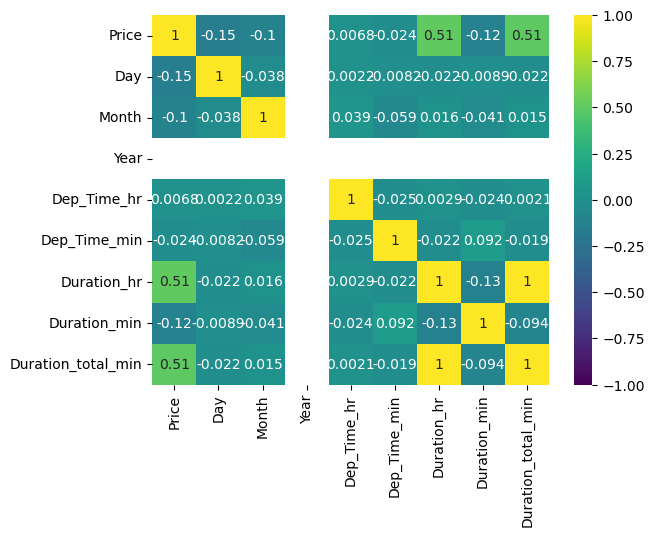

In [35]:
sns.heatmap(correlation,
            annot = True,
            cmap = 'viridis',
            vmin= -1 ,
            vmax= 1
           )

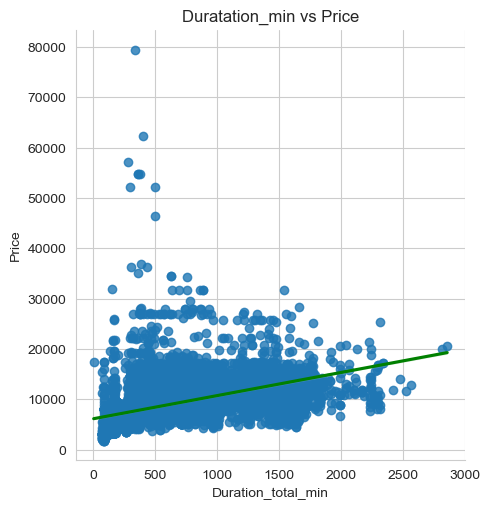

In [36]:
''' Duration was highly correlated with price so need to visualize using lmplot '''

sns.set_style('whitegrid')
sns.lmplot(
    x = 'Duration_total_min',
    y = 'Price',
    line_kws={'color':'green'},
    data = data
)
plt.title('Duratation_min vs Price')
plt.show()

In [37]:
# highwind

In [38]:
def classify(x):
    if (x>3) and (x<7):
        return 'early_morning'
    elif (x>7) and (x<=12):
        return 'Morning'
    elif (x>12) and (x<=14):
        return 'Afternoon'
    elif (x>4) and (x<=21):
        return 'night'
    else : 
        return 'late_night'

In [39]:
df1 = data['Dep_Time_hr'].apply(classify)
df1

0           late_night
1        early_morning
2              Morning
3                night
4                night
             ...      
10678            night
10679            night
10680          Morning
10681          Morning
10682          Morning
Name: Dep_Time_hr, Length: 10682, dtype: object

In [40]:
df2 = pd.DataFrame(df1.value_counts())
df2

,count
Dep_Time_hr,
night,4507
Morning,2906
early_morning,1486
Afternoon,940
late_night,843


' Night flights are used most by Passangers '

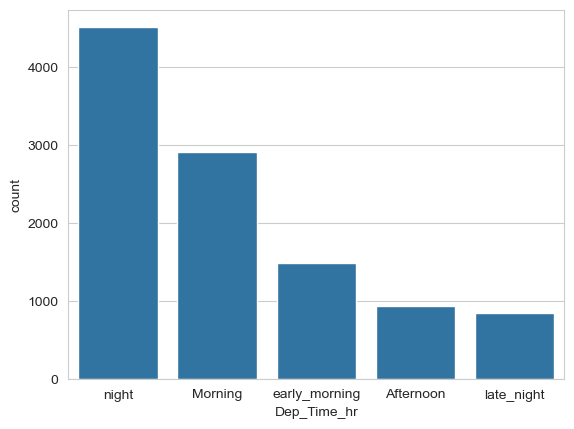

In [41]:

sns.barplot(x = 'Dep_Time_hr' , y = 'count' , data = df2)

''' Night flights are used most by Passangers '''

### Average ticket price for all Airline

In [134]:
avg_ticket_price = pd.DataFrame(round(data.groupby('Airline')['Price'].median().sort_values(ascending=False),2))
avg_ticket_price

,Price
Airline,
Jet Airways Business,54747.0
Jet Airways,11467.0
Multiple carriers Premium economy,11269.0
Multiple carriers,10197.0
Air India,9443.0
Vistara Premium economy,9125.0
Vistara,7980.0
Air Asia,5162.0
GoAir,5135.0


## One-Hot-Encoding  (feature encoding)

* Target guided feature encoding
* Perform manual encoding

In [135]:
for col in data.columns :
    if data[col].dtype == 'object':
        print(col)

Airline
Source
Destination
Route
Duration
Total_Stops
Additional_Info


In [136]:
data['Source'].unique()

array(['Banglore', 'Kolkata', 'Delhi', 'Chennai', 'Mumbai'], dtype=object)

In [137]:
source_dummy = pd.get_dummies(data['Source']).astype(int)
source_dummy.head(3)

,Banglore,Chennai,Delhi,Kolkata,Mumbai
0,1,0,0,0,0
1,0,0,0,1,0
2,0,0,1,0,0


In [138]:
data = pd.concat([data , source_dummy] , axis = 1)

In [139]:
data.head(2)

,Airline,Date_of_Journey,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Day,...,Dep_Time_hr,Dep_Time_min,Duration_hr,Duration_min,Duration_total_min,Banglore,Chennai,Delhi,Kolkata,Mumbai
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,2h 50m,non-stop,No info,3897,24,...,22,20,2,50,170,1,0,0,0,0
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,7h 25m,2 stops,No info,7662,1,...,5,50,7,25,445,0,0,0,1,0


### Targeted Encoding (Using mean)

In [140]:
# Target encoding for median_price
median_price = data.groupby('Airline')['Price'].median()
median_price

Airline
Air Asia                              5162.0
Air India                             9443.0
GoAir                                 5135.0
IndiGo                                5000.0
Jet Airways                          11467.0
Jet Airways Business                 54747.0
Multiple carriers                    10197.0
Multiple carriers Premium economy    11269.0
SpiceJet                              3873.0
Trujet                                4140.0
Vistara                               7980.0
Vistara Premium economy               9125.0
Name: Price, dtype: float64

In [141]:
rank_values = median_price.rank()
data['airline_rank'] = data['Airline'].map(rank_values).astype('int')

In [142]:
rank_values

Airline
Air Asia                              5.0
Air India                             8.0
GoAir                                 4.0
IndiGo                                3.0
Jet Airways                          11.0
Jet Airways Business                 12.0
Multiple carriers                     9.0
Multiple carriers Premium economy    10.0
SpiceJet                              1.0
Trujet                                2.0
Vistara                               6.0
Vistara Premium economy               7.0
Name: Price, dtype: float64

In [143]:
data['airline_rank']

0         3
1         8
2        11
3         3
4         3
         ..
10678     5
10679     8
10680    11
10681     6
10682     8
Name: airline_rank, Length: 10682, dtype: int32

In [144]:
data['Destination'].unique()

array(['New Delhi', 'Banglore', 'Cochin', 'Kolkata', 'Delhi', 'Hyderabad'],
      dtype=object)

In [145]:
# Target Encoding for Destination
data['Destination'] = np.where(data['Destination'] == 'New Delhi', 'Delhi', data['Destination'] )

In [146]:
median_price_desti = data.groupby('Destination')['Price'].median()
median_price_desti

Destination
Banglore      9345.0
Cochin       10262.0
Delhi         6121.0
Hyderabad     3342.0
Kolkata       3850.0
Name: Price, dtype: float64

In [147]:
destination_rank = median_price_desti.rank().astype('int')
destination_rank

Destination
Banglore     4
Cochin       5
Delhi        3
Hyderabad    1
Kolkata      2
Name: Price, dtype: int32

In [148]:
data['Destination'] = data['Destination'].map(destination_rank).astype('int')

#### Label encoding using map function

In [149]:
data['Total_Stops'].unique()

array(['non-stop', '2 stops', '1 stop', '3 stops', '4 stops'],
      dtype=object)

In [150]:
ranks = {'non-stop':1, '2 stops':3, '1 stop':2, '3 stops':4, '4 stops':5}

In [151]:
data['total_stops_rank'] = data['Total_Stops'].map(ranks)

In [152]:
data['total_stops_rank']

0        1
1        3
2        3
3        2
4        2
        ..
10678    1
10679    1
10680    1
10681    1
10682    3
Name: total_stops_rank, Length: 10682, dtype: int64

In [153]:
data.columns

Index(['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Route',
       'Duration', 'Total_Stops', 'Additional_Info', 'Price', 'Day', 'Month',
       'Year', 'Dep_Time_hr', 'Dep_Time_min', 'Duration_hr', 'Duration_min',
       'Duration_total_min', 'Banglore', 'Chennai', 'Delhi', 'Kolkata',
       'Mumbai', 'airline_rank', 'total_stops_rank'],
      dtype='object')

In [154]:
# Removing extra usless features
columns = ['Additional_Info','Source','Route','Year','Duration_total_min','Duration_min']

In [155]:
extra_columns = ['Airline','Duration','Total_Stops','Date_of_Journey']

In [156]:
data.drop(columns = columns , axis = 1 , inplace = True)

In [157]:
data.drop(columns = extra_columns , axis = 1 , inplace = True)

In [158]:
data.columns

Index(['Destination', 'Price', 'Day', 'Month', 'Dep_Time_hr', 'Dep_Time_min',
       'Duration_hr', 'Banglore', 'Chennai', 'Delhi', 'Kolkata', 'Mumbai',
       'airline_rank', 'total_stops_rank'],
      dtype='object')

In [159]:
data.head(1)

,Destination,Price,Day,Month,Dep_Time_hr,Dep_Time_min,Duration_hr,Banglore,Chennai,Delhi,Kolkata,Mumbai,airline_rank,total_stops_rank
0,3,3897,24,3,22,20,2,1,0,0,0,0,3,1


In [160]:
data.columns

Index(['Destination', 'Price', 'Day', 'Month', 'Dep_Time_hr', 'Dep_Time_min',
       'Duration_hr', 'Banglore', 'Chennai', 'Delhi', 'Kolkata', 'Mumbai',
       'airline_rank', 'total_stops_rank'],
      dtype='object')

### Outlier detection

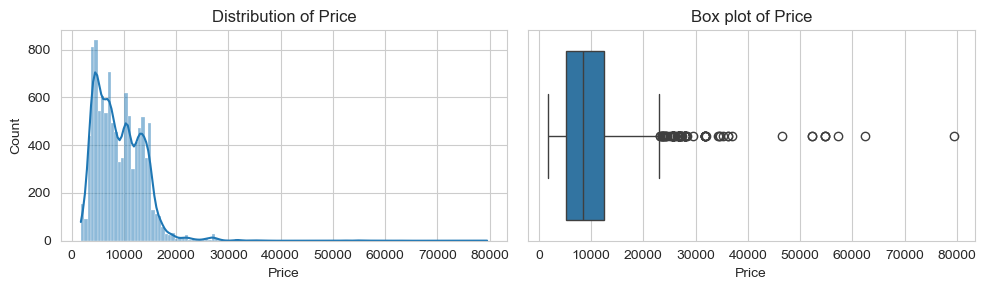

In [161]:
fig , (ax1,ax2) = plt.subplots(1,2,figsize=(10,3))

# ploting distribution plot
sns.histplot(data['Price'],kde = True ,ax = ax1)
ax1.set_title('Distribution of Price')

# Box plot
sns.boxplot(x = data['Price'],ax=ax2)
ax2.set_title('Box plot of Price')

plt.tight_layout()
plt.show()

In [162]:
Q1 = data['Price'].quantile(0.25)
Q3 = data['Price'].quantile(0.75)
IQR = Q3 - Q1

print('Q1 : ', Q1)
print('Q3 : ', Q3)
print('IQR : ',IQR)

Q1 :  5277.0
Q3 :  12373.0
IQR :  7096.0


In [163]:
upper_bound = Q3 + 1.5*IQR
upper_bound

23017.0

In [164]:
outliers = data[data['Price'] > 23017]['Price']
outliers.nunique()

44

In [165]:
data['Price'] = np.where(data['Price']>23017,data['Price'].median() , data['Price'])   # Used median for outliers

### Feature Selection

In [166]:
data.head(1)

,Destination,Price,Day,Month,Dep_Time_hr,Dep_Time_min,Duration_hr,Banglore,Chennai,Delhi,Kolkata,Mumbai,airline_rank,total_stops_rank
0,3,3897.0,24,3,22,20,2,1,0,0,0,0,3,1


In [167]:
data['Destination'].unique()

array([3, 4, 5, 2, 1])

In [168]:
data.columns

Index(['Destination', 'Price', 'Day', 'Month', 'Dep_Time_hr', 'Dep_Time_min',
       'Duration_hr', 'Banglore', 'Chennai', 'Delhi', 'Kolkata', 'Mumbai',
       'airline_rank', 'total_stops_rank'],
      dtype='object')

In [169]:
X = data.drop('Price', axis = 1 )

In [170]:
y = data['Price']

#### Feature importance 

In [171]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators = 100 , random_state = 42)

In [172]:
rf.fit(X,y)

RandomForestRegressor(random_state=42)

In [173]:
rf.feature_importances_

array([0.01018724, 0.08649195, 0.07498301, 0.05215911, 0.04179191,
       0.54408392, 0.00366471, 0.00184303, 0.00367566, 0.00804869,
       0.00346531, 0.14602013, 0.02358532])

In [174]:
X.columns

Index(['Destination', 'Day', 'Month', 'Dep_Time_hr', 'Dep_Time_min',
       'Duration_hr', 'Banglore', 'Chennai', 'Delhi', 'Kolkata', 'Mumbai',
       'airline_rank', 'total_stops_rank'],
      dtype='object')

In [175]:
feature_importance = pd.DataFrame({
                          'features': X.columns,
                          'importance' : rf.feature_importances_
                    }).sort_values(by = 'importance' , ascending = False)

feature_importance

,features,importance
5,Duration_hr,0.544084
11,airline_rank,0.146020
1,Day,0.086492
2,Month,0.074983
3,Dep_Time_hr,0.052159
4,Dep_Time_min,0.041792
12,total_stops_rank,0.023585
0,Destination,0.010187
9,Kolkata,0.008049
8,Delhi,0.003676


# ML model (Random Forest)

In [176]:
''' Train - Test Spliting '''

from sklearn.model_selection import train_test_split
X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.2,random_state = 74)

In [177]:
from sklearn.ensemble import RandomForestRegressor

In [178]:
md = RandomForestRegressor(n_estimators = 100 , random_state = 44) 

In [179]:
md = md.fit(X_train,y_train)
md

RandomForestRegressor(random_state=44)

In [180]:
y_pred = md.predict(X_test)
y_pred

array([ 6477.89      , 15303.84      ,  6342.725     , ...,
       15716.11666667, 14858.37483333,  6189.85      ])

#### Model Evaluation

In [181]:
''' Calculate r2 score , MAE and MAPE '''

from sklearn.metrics import r2_score , mean_absolute_error , mean_absolute_percentage_error

# r2 score
r2 = r2_score(y_test,y_pred)

# MAE
mae = mean_absolute_error(y_test,y_pred)

# MAPE
mape = mean_absolute_percentage_error(y_test,y_pred)

print('R2 Score :', r2)
print('MAPE :', mape *100,'%')
print('MAE :', mae)



R2 Score : 0.7623398624606208
MAPE : 14.282248614688564 %
MAE : 1238.398660269889


#### Hypertuning


In [209]:
from sklearn.model_selection import RandomizedSearchCV

In [210]:
rf = RandomForestRegressor()

In [211]:
n_estimators = [int(x) for x in np.linspace(100,1000,5)]

max_depth = [int(x) for x in np.linspace(5,30,5)]

max_features = ['auto' , 'sqrt']

min_samples_split = [5,10,15,100]

In [212]:
rd_grid = {
    'n_estimators' : n_estimators ,
    'max_depth' : max_depth ,
    'max_features' : max_features ,
    'min_samples_split' : min_samples_split
}

In [213]:
rd_grid

{'n_estimators': [100, 325, 550, 775, 1000],
 'max_depth': [5, 11, 17, 23, 30],
 'max_features': ['auto', 'sqrt'],
 'min_samples_split': [5, 10, 15, 100]}

In [214]:
rf_random = RandomizedSearchCV(estimator = rf ,param_distributions = rd_grid ,cv = 3 ,n_jobs = -1,verbose = 2 )

In [215]:
rf_random.fit(X_train,y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


RandomizedSearchCV(cv=3, estimator=RandomForestRegressor(), n_jobs=-1,
                   param_distributions={'max_depth': [5, 11, 17, 23, 30],
                                        'max_features': ['auto', 'sqrt'],
                                        'min_samples_split': [5, 10, 15, 100],
                                        'n_estimators': [100, 325, 550, 775,
                                                         1000]},
                   verbose=2)

In [216]:
rf_random.best_params_

{'n_estimators': 550,
 'min_samples_split': 10,
 'max_features': 'auto',
 'max_depth': 17}

In [217]:
rf_random.best_score_

0.8148245099215754

### Final Model

In [223]:
best_model = rf_random.best_estimator_
best_model

RandomForestRegressor(max_depth=17, max_features='auto', min_samples_split=10,
                      n_estimators=550)

In [225]:
yf_pred = best_model.predict(X_test)
yf_pred

array([ 6567.47589443, 13920.53107407,  6134.05515008, ...,
       16219.85424521, 14252.33657333,  6230.14531745])

In [226]:
''' Calculate r2 score , MAE and MAPE '''

from sklearn.metrics import r2_score , mean_absolute_error , mean_absolute_percentage_error

# r2 score
r2 = r2_score(y_test,yf_pred)

# MAE
mae = mean_absolute_error(y_test,yf_pred)

# MAPE
mape = mean_absolute_percentage_error(y_test,yf_pred)

print('R2 Score :', r2)
print('MAPE :', mape *100,'%')
print('MAE :', mae)



R2 Score : 0.7961505620296747
MAPE : 13.78049749779561 %
MAE : 1188.2048870313818


##### Saving Model

In [228]:
import pickle

In [234]:
with open('model_pickle.pkl','wb') as f :
    pickle.dump(best_model,f)

In [235]:
with open('model_pickle.pkl','rb') as f :
    model = pickle.load(f)

In [236]:
model.predict(X_test)

array([ 6567.47589443, 13920.53107407,  6134.05515008, ...,
       16219.85424521, 14252.33657333,  6230.14531745])